# Advanced: Fed-Batch CHO Bioreactor Model, Simulation and Parameter Exploration
This notebook simulates a kinetic model of a fed-batch CHO bioreactor and explores how model parameters shape the bioreactor trajectory. The CHO model is the data-generating process used to train the LSTM in the [companion example](CHEME-5820-L12c-Example-LSTM-CHO-Spring-2026.ipynb).

> __Learning Objectives:__
>
> By the end of this notebook, you should be able to:
>
> * __Describe the fed-batch CHO bioreactor model:__ Identify the seven state variables, write the mass balance ODEs, and explain how the Monod growth law with by-product inhibition governs cell behavior.
> * __Explore how growth kinetics and by-product inhibition shape the trajectory:__ Vary the maximum growth rate and inhibition constants and observe how each change affects biomass, antibody titer, and by-product accumulation.
> * __Explore how process parameters control productivity:__ Vary the feed policy and yield coefficients and observe how these engineering handles determine the tradeoff between productivity and by-product accumulation.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, and setting up required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-12/L12c`


In addition to standard Julia libraries, this notebook uses [the `OrdinaryDiffEq.jl` package](https://github.com/SciML/OrdinaryDiffEq.jl) for solving the CHO bioreactor ODE system and [the `PrettyTables.jl` package](https://ronisbr.github.io/PrettyTables.jl/stable/) for formatted table output. The CHO kinetic model is implemented in the `src/` directory.

### Implementations
We use helper functions defined in the `src/` directory:

| Function | Source | Description |
| --- | --- | --- |
| [`build_default_parameters(...)`](src/Parameters.jl) | `src/Parameters.jl` | Construct a `MyFedBatchCHOParameters` instance with default kinetic values |
| [`simulate_fedbatch(...)`](src/Simulation.jl) | `src/Simulation.jl` | Integrate the CHO ODE system with glucose-triggered square wave feeding |
| [`pretty_table(...)`](https://ronisbr.github.io/PrettyTables.jl/stable/) | `PrettyTables.jl` | Format and display a table in the terminal |

### Constants
We define simulation and parameter sweep constants used throughout the notebook.

In [2]:
# initial conditions: [V (L), X (gDW/L), S_glc (mM), S_gln (mM), P (mg/L), Lac (mM), Amm (mM)] -
u0_baseline = [10.0, 0.3, 25.0, 8.0, 0.0, 0.0, 0.0];

# simulation time span and output resolution -
tspan  = (0.0, 336.0);   # 336 hours = 14 days
saveat = 1.0;             # save every 1 hour (337 time points)

# state index mapping: 1=V, 2=X, 3=Glc, 4=Gln, 5=P, 6=Lac, 7=Amm -
state_names = ["V (L)", "X (gDW/L)", "Glc (mM)", "Gln (mM)", "mAb (mg/L)", "Lac (mM)", "Amm (mM)"];

___

## Task 1: Simulate the Baseline Fed-Batch CHO Bioreactor
We simulate a kinetic model of CHO cell growth and antibody production under a glucose-triggered feed policy. The model tracks seven state variables coupled through yield-based kinetics and Monod growth with by-product inhibition.

> __Fed-batch CHO mass balances__
>
> The model tracks seven state variables: $V$ (L, reactor volume), $X$ (gDW/L, biomass), $S_{glc}$ (mM, glucose), $S_{gln}$ (mM, glutamine), $P$ (mg/L, antibody), $Lac$ (mM, lactate), and $Amm$ (mM, ammonia). The state equations are:
> $$
\begin{align*}
\frac{dV}{dt} &= F \\
\frac{dX}{dt} &= (\mu - \mu_d - D)\,X \\
\frac{dS_{glc}}{dt} &= D(S_{glc,f} - S_{glc}) - q_{glc}\,X \\
\frac{dS_{gln}}{dt} &= D(S_{gln,f} - S_{gln}) - q_{gln}\,X \\
\frac{dP}{dt} &= q_P\,X - D\,P \\
\frac{dLac}{dt} &= q_{lac}\,X - D\,Lac \\
\frac{dAmm}{dt} &= q_{amm}\,X - D\,Amm
\end{align*}
> $$
> where $F$ (L/h) is the volumetric feed rate, $D = F/V$ (1/h) is the dilution rate, $\mu$ (1/h) is the specific growth rate, $\mu_d$ (1/h) is the specific death rate, and $q_{(\cdot)}$ terms are specific uptake or formation rates.

We use [the `build_default_parameters(...)` function](src/Parameters.jl) to construct the baseline parameter set and [the `simulate_fedbatch(...)` function](src/Simulation.jl) to integrate the ODE system. The baseline parameters are stored in `p_baseline::MyFedBatchCHOParameters`, the ODE solution in `sol_baseline`, and the time vector in `t::Vector{Float64}` (hours).

In [3]:
# baseline feed policy: moderate feed rate, tight glucose band -
p_baseline = build_default_parameters(;
    F_max   = 0.10,        # maximum feed rate: 0.10 L/h
    Glc_min = 2.0,         # turn feed ON when glucose < 2 mM
    Glc_max = 20.0,        # turn feed OFF when glucose > 20 mM
);

# integrate the ODE system over 14 days -
sol_baseline = simulate_fedbatch(p_baseline; u0 = u0_baseline, tspan = tspan, saveat = saveat);
t = sol_baseline.t; # time vector (hours)
println("Simulation complete: $(length(t)) time points over $(tspan[2]) hours");

Simulation complete: 345 time points over 336.0 hours


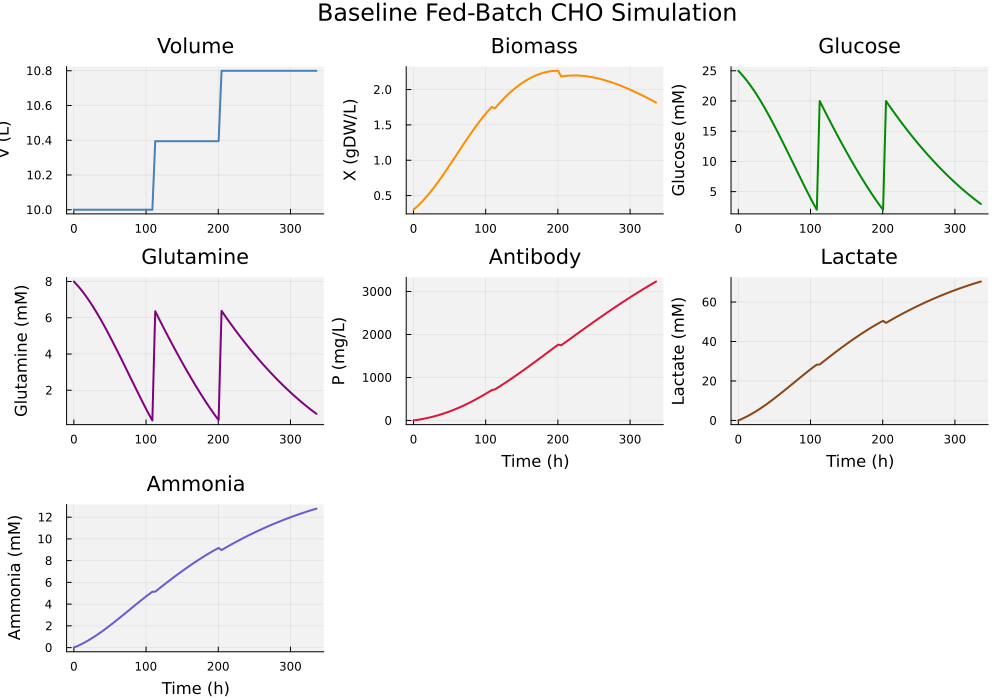

In [4]:
let
    sol = sol_baseline;

    # extract each state from the ODE solution vector -
    # sol.u[i] is the state vector at time point i -
    V     = [sol.u[i][1] for i in 1:length(t)]; # reactor volume (L)
    X     = [sol.u[i][2] for i in 1:length(t)]; # biomass (gDW/L)
    S_glc = [sol.u[i][3] for i in 1:length(t)]; # glucose (mM)
    S_gln = [sol.u[i][4] for i in 1:length(t)]; # glutamine (mM)
    P     = [sol.u[i][5] for i in 1:length(t)]; # antibody product (mg/L)
    Lac   = [sol.u[i][6] for i in 1:length(t)]; # lactate (mM)
    Amm   = [sol.u[i][7] for i in 1:length(t)]; # ammonia (mM)

    # create one subplot per state -
    p1 = plot(t, V,     ylabel="V (L)",          label=false, lw=2, color=:steelblue,   title="Volume",    background_color_inside=:gray95);
    p2 = plot(t, X,     ylabel="X (gDW/L)",      label=false, lw=2, color=:darkorange,  title="Biomass",   background_color_inside=:gray95);
    p3 = plot(t, S_glc, ylabel="Glucose (mM)",   label=false, lw=2, color=:green4,      title="Glucose",   background_color_inside=:gray95);
    p4 = plot(t, S_gln, ylabel="Glutamine (mM)", label=false, lw=2, color=:purple,      title="Glutamine", background_color_inside=:gray95);
    p5 = plot(t, P,     ylabel="P (mg/L)",       label=false, lw=2, color=:crimson,     title="Antibody",  background_color_inside=:gray95);
    p6 = plot(t, Lac,   ylabel="Lactate (mM)",   label=false, lw=2, color=:saddlebrown, title="Lactate",   background_color_inside=:gray95);
    p7 = plot(t, Amm,   ylabel="Ammonia (mM)",   label=false, lw=2, color=:slateblue,   title="Ammonia",   background_color_inside=:gray95);

    # add x-axis label to bottom row only -
    for p in [p5, p6, p7]
        plot!(p, xlabel="Time (h)")
    end

    # combine into a 3x3 grid -
    plot(p1, p2, p3, p4, p5, p6, p7, layout=(3, 3), size=(1000, 700),
        plot_title="Baseline Fed-Batch CHO Simulation")
end

The baseline trajectory shows the expected fed-batch dynamics: volume rises as feed is added, biomass peaks and then declines as by-products accumulate, and glucose oscillates as the feed cycles on and off. Next, we explore how growth kinetics and by-product inhibition shape these dynamics.
___

## Task 2: Explore Growth Kinetics and By-Product Inhibition
We explore how the maximum growth rate $\mu_{max}$ and the by-product inhibition constants $K_{I,lac}$ and $K_{I,amm}$ affect the bioreactor trajectory.

> __Monod growth rate with inhibition__
>
> $$
\mu = \mu_{\max}
\underbrace{\left(\frac{S_{glc}}{K_{glc}+S_{glc}}\right)}_{\text{glucose limitation}}
\underbrace{\left(\frac{S_{gln}}{K_{gln}+S_{gln}}\right)}_{\text{glutamine limitation}}
\underbrace{\left(\frac{K_{I,lac}}{K_{I,lac}+Lac}\right)}_{\text{lactate inhibition}}
\underbrace{\left(\frac{K_{I,amm}}{K_{I,amm}+Amm}\right)}_{\text{ammonia inhibition}}
> $$
> The two substrate terms reduce growth when glucose or glutamine is scarce (Monod saturation). The two inhibition terms reduce growth as lactate and ammonia accumulate.

### 2a. Maximum Growth Rate
We sweep $\mu_{max}$ across three values while holding all other parameters at baseline.

> __Clone selection and cell line engineering__ is the first step in CHO biologics manufacturing. Cell line development screens thousands of clones to balance growth rate against productivity. A fast-growing clone ($\mu_{max} \approx 0.05$ 1/h) reaches high cell density quickly but may produce more by-products that inhibit growth before the culture matures. A slower clone ($\mu_{max} \approx 0.025$ 1/h) grows more gradually but may sustain viable biomass longer, producing more antibody over the full run.

The four subplots show biomass $X$ (gDW/L), antibody titer $P$ (mg/L), glucose $S_{glc}$ (mM), and lactate $Lac$ (mM) trajectories for each $\mu_{max}$ value.

In [5]:
mu_max_results = let

    # sweep mu_max: low, baseline, high -
    mu_max_values = [0.025, 0.035, 0.050]; # 1/h
    labels = ["\u03bc_max = 0.025 (low)", "\u03bc_max = 0.035 (baseline)", "\u03bc_max = 0.050 (high)"];
    n = length(mu_max_values);

    # simulate each mu_max value -
    results = Vector{Any}(undef, n);
    for (i, mu) in enumerate(mu_max_values)
        p = build_default_parameters(; F_max=0.10, Glc_min=2.0, Glc_max=20.0, mu_max=mu);
        results[i] = simulate_fedbatch(p; u0=copy(u0_baseline), tspan=tspan, saveat=saveat);
    end

    # return results -
    (values=mu_max_values, labels=labels, solutions=results)
end;

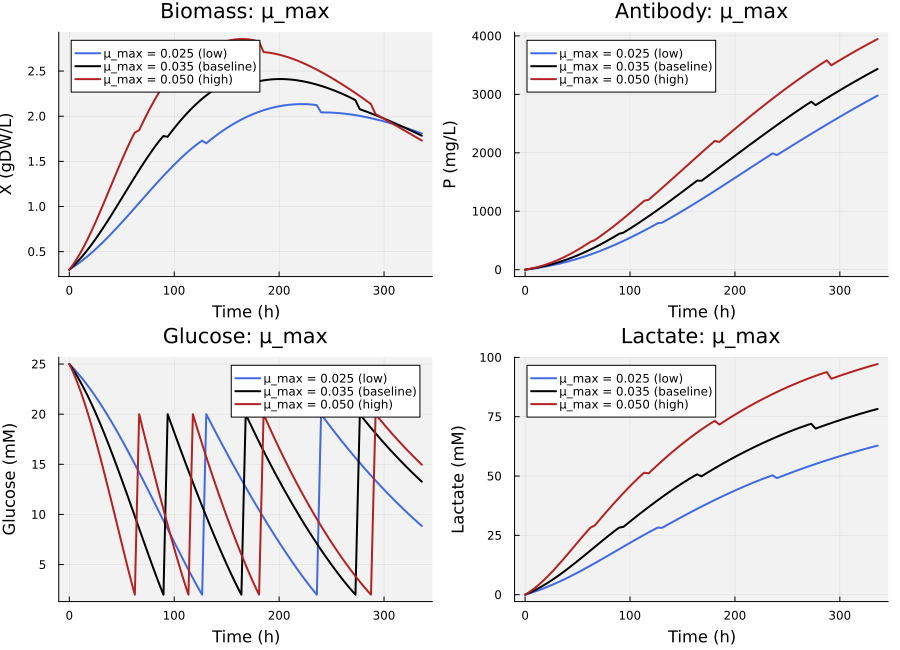

In [6]:
let
    vals = mu_max_results;
    colors = [:royalblue, :black, :firebrick];

    # initialize subplots -
    p_X = plot(ylabel="X (gDW/L)",    xlabel="Time (h)", title="Biomass: \u03bc_max",  legend=:topleft,  background_color_inside=:gray95);
    p_P = plot(ylabel="P (mg/L)",     xlabel="Time (h)", title="Antibody: \u03bc_max", legend=:topleft,  background_color_inside=:gray95);
    p_G = plot(ylabel="Glucose (mM)", xlabel="Time (h)", title="Glucose: \u03bc_max",  legend=:topright, background_color_inside=:gray95);
    p_L = plot(ylabel="Lactate (mM)", xlabel="Time (h)", title="Lactate: \u03bc_max",  legend=:topleft,  background_color_inside=:gray95);

    # overlay each mu_max value -
    for (i, sol) in enumerate(vals.solutions)
        X_t   = [sol.u[j][2] for j in 1:length(sol.t)]; # biomass (index 2) -
        P_t   = [sol.u[j][5] for j in 1:length(sol.t)]; # antibody (index 5) -
        Glc_t = [sol.u[j][3] for j in 1:length(sol.t)]; # glucose (index 3) -
        Lac_t = [sol.u[j][6] for j in 1:length(sol.t)]; # lactate (index 6) -
        plot!(p_X, sol.t, X_t,   label=vals.labels[i], lw=2, color=colors[i]);
        plot!(p_P, sol.t, P_t,   label=vals.labels[i], lw=2, color=colors[i]);
        plot!(p_G, sol.t, Glc_t, label=vals.labels[i], lw=2, color=colors[i]);
        plot!(p_L, sol.t, Lac_t, label=vals.labels[i], lw=2, color=colors[i]);
    end

    plot(p_X, p_P, p_G, p_L, layout=(2, 2), size=(900, 650))
end

Higher $\mu_{max}$ produces more biomass early but also generates more lactate, which accelerates growth inhibition and can reduce the final antibody titer. Next, we examine how sensitive the culture is to the by-products it produces.

### 2b. By-Product Inhibition
We sweep the lactate inhibition constant $K_{I,lac}$ and the ammonia inhibition constant $K_{I,amm}$ separately.

> __Lactate and ammonia management__ is a central challenge in CHO cell culture. Lactate accumulates from aerobic glycolysis (the Warburg effect, where CHO cells preferentially ferment glucose even in the presence of oxygen). Ammonia is a by-product of glutamine metabolism. Both inhibit growth above threshold concentrations. Media formulation (e.g., replacing glutamine with glutamate to reduce ammonia), metabolic engineering (e.g., glutamine synthetase expression systems), and process control (e.g., maintaining low glucose to reduce lactate overflow) are used in manufacturing to manage by-product accumulation.

The four subplots compare biomass $X$ (gDW/L) and by-product trajectories for lactate inhibition (top row) and ammonia inhibition (bottom row).

In [7]:
inhib_results = let

    # --- Lactate inhibition sweep ---
    KI_lac_values = [20.0, 43.0, 80.0]; # mM (low = sensitive, high = tolerant)
    labels_lac = ["K_I,lac = 20 mM (sensitive)", "K_I,lac = 43 mM (baseline)", "K_I,lac = 80 mM (tolerant)"];
    sols_lac = Vector{Any}(undef, 3);
    for (i, KI) in enumerate(KI_lac_values)
        p = build_default_parameters(; F_max=0.10, Glc_min=2.0, Glc_max=20.0, K_I_lac=KI);
        sols_lac[i] = simulate_fedbatch(p; u0=copy(u0_baseline), tspan=tspan, saveat=saveat);
    end

    # --- Ammonia inhibition sweep ---
    KI_amm_values = [3.0, 8.0, 15.0]; # mM
    labels_amm = ["K_I,amm = 3 mM (sensitive)", "K_I,amm = 8 mM (baseline)", "K_I,amm = 15 mM (tolerant)"];
    sols_amm = Vector{Any}(undef, 3);
    for (i, KI) in enumerate(KI_amm_values)
        p = build_default_parameters(; F_max=0.10, Glc_min=2.0, Glc_max=20.0, K_I_amm=KI);
        sols_amm[i] = simulate_fedbatch(p; u0=copy(u0_baseline), tspan=tspan, saveat=saveat);
    end

    # return results -
    (lac_labels=labels_lac, lac_sols=sols_lac, amm_labels=labels_amm, amm_sols=sols_amm)
end;

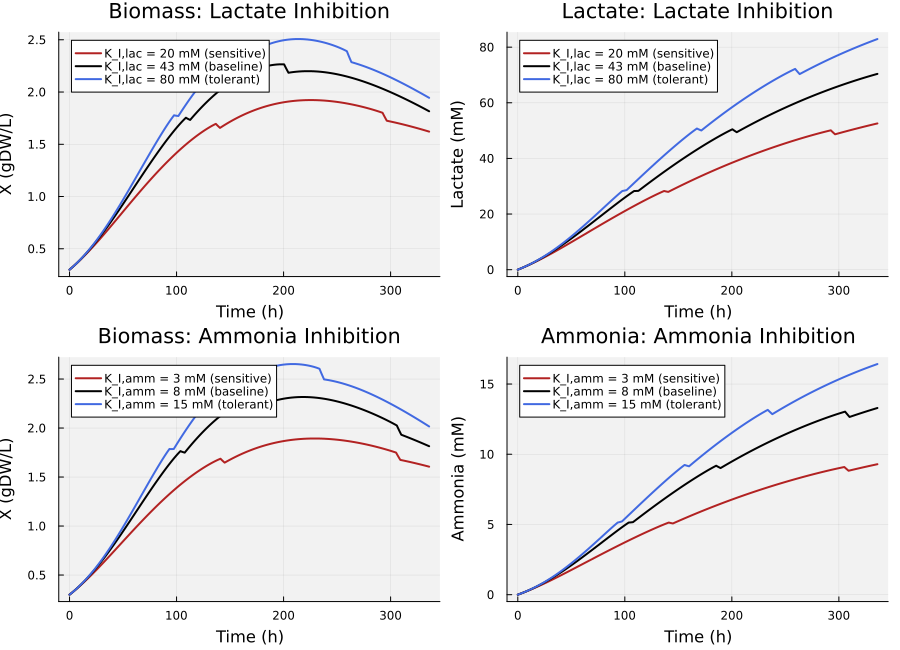

In [8]:
let
    res = inhib_results;
    colors = [:firebrick, :black, :royalblue];

    # --- Top row: lactate inhibition ---
    p1 = plot(ylabel="X (gDW/L)",    xlabel="Time (h)", title="Biomass: Lactate Inhibition", legend=:topleft, background_color_inside=:gray95);
    p2 = plot(ylabel="Lactate (mM)", xlabel="Time (h)", title="Lactate: Lactate Inhibition", legend=:topleft, background_color_inside=:gray95);
    for (i, sol) in enumerate(res.lac_sols)
        X_t   = [sol.u[j][2] for j in 1:length(sol.t)]; # biomass (index 2) -
        Lac_t = [sol.u[j][6] for j in 1:length(sol.t)]; # lactate (index 6) -
        plot!(p1, sol.t, X_t,   label=res.lac_labels[i], lw=2, color=colors[i]);
        plot!(p2, sol.t, Lac_t, label=res.lac_labels[i], lw=2, color=colors[i]);
    end

    # --- Bottom row: ammonia inhibition ---
    p3 = plot(ylabel="X (gDW/L)",    xlabel="Time (h)", title="Biomass: Ammonia Inhibition", legend=:topleft, background_color_inside=:gray95);
    p4 = plot(ylabel="Ammonia (mM)", xlabel="Time (h)", title="Ammonia: Ammonia Inhibition", legend=:topleft, background_color_inside=:gray95);
    for (i, sol) in enumerate(res.amm_sols)
        X_t   = [sol.u[j][2] for j in 1:length(sol.t)]; # biomass (index 2) -
        Amm_t = [sol.u[j][7] for j in 1:length(sol.t)]; # ammonia (index 7) -
        plot!(p3, sol.t, X_t,   label=res.amm_labels[i], lw=2, color=colors[i]);
        plot!(p4, sol.t, Amm_t, label=res.amm_labels[i], lw=2, color=colors[i]);
    end

    plot(p1, p2, p3, p4, layout=(2, 2), size=(900, 650))
end

Cells with lower inhibition constants show earlier growth arrest as by-products accumulate. Cells with higher inhibition constants sustain growth longer and achieve higher peak biomass and antibody titer. Having explored the biological parameters, we now turn to the process parameters that an engineer can control.
___

## Task 3: Explore Process Parameters
The growth kinetics and inhibition constants are biological properties of the cell line. The feed policy and yield coefficients, by contrast, are determined by process design and can be optimized by the engineer.

### 3a. Feed Rate
We sweep the maximum feed rate $F_{max}$ while holding the glucose band at baseline values.

> __Fed-batch process control__ determines how nutrients are delivered to the culture. The feed rate $F_{max}$ controls the volume of concentrated feed solution added per hour. Too fast a feed rate produces substrate overflow (high glucose drives lactate production through the Warburg effect) and excessive dilution. Too slow a feed rate starves cells and limits growth. Modern manufacturing facilities use Process Analytical Technology (PAT) to monitor metabolite levels and adjust feed rates in real time, but the fundamental tradeoff between nutrient supply and by-product management remains.

The four subplots show biomass $X$ (gDW/L), antibody $P$ (mg/L), volume $V$ (L), and glucose $S_{glc}$ (mM) trajectories for each $F_{max}$ value.

In [9]:
fmax_results = let

    # sweep F_max: slow, baseline, fast -
    F_max_values = [0.025, 0.10, 0.50]; # L/h
    labels = ["F_max = 0.025 L/h (slow)", "F_max = 0.10 L/h (baseline)", "F_max = 0.50 L/h (fast)"];
    n = length(F_max_values);

    # simulate each F_max value -
    results = Vector{Any}(undef, n);
    for (i, Fmax) in enumerate(F_max_values)
        p = build_default_parameters(; F_max=Fmax, Glc_min=2.0, Glc_max=20.0);
        results[i] = simulate_fedbatch(p; u0=copy(u0_baseline), tspan=tspan, saveat=saveat);
    end

    # return results -
    (values=F_max_values, labels=labels, solutions=results)
end;

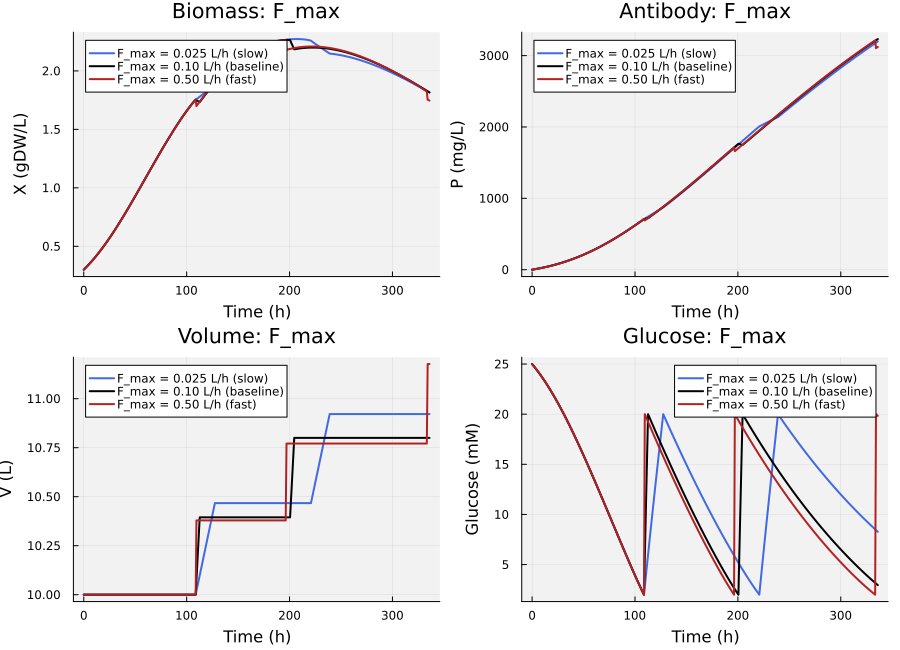

In [10]:
let
    vals = fmax_results;
    colors = [:royalblue, :black, :firebrick];

    # initialize subplots -
    p_X = plot(ylabel="X (gDW/L)",    xlabel="Time (h)", title="Biomass: F_max",  legend=:topleft,  background_color_inside=:gray95);
    p_P = plot(ylabel="P (mg/L)",     xlabel="Time (h)", title="Antibody: F_max", legend=:topleft,  background_color_inside=:gray95);
    p_V = plot(ylabel="V (L)",        xlabel="Time (h)", title="Volume: F_max",   legend=:topleft,  background_color_inside=:gray95);
    p_G = plot(ylabel="Glucose (mM)", xlabel="Time (h)", title="Glucose: F_max",  legend=:topright, background_color_inside=:gray95);

    # overlay each F_max value -
    for (i, sol) in enumerate(vals.solutions)
        X_t = [sol.u[j][2] for j in 1:length(sol.t)]; # biomass (index 2) -
        P_t = [sol.u[j][5] for j in 1:length(sol.t)]; # antibody (index 5) -
        V_t = [sol.u[j][1] for j in 1:length(sol.t)]; # volume (index 1) -
        G_t = [sol.u[j][3] for j in 1:length(sol.t)]; # glucose (index 3) -
        plot!(p_X, sol.t, X_t, label=vals.labels[i], lw=2, color=colors[i]);
        plot!(p_P, sol.t, P_t, label=vals.labels[i], lw=2, color=colors[i]);
        plot!(p_V, sol.t, V_t, label=vals.labels[i], lw=2, color=colors[i]);
        plot!(p_G, sol.t, G_t, label=vals.labels[i], lw=2, color=colors[i]);
    end

    plot(p_X, p_P, p_V, p_G, layout=(2, 2), size=(900, 650))
end

A faster feed rate supports more biomass and higher titer but also increases reactor volume and dilution. Next, we explore how the glucose control band shapes the feeding pattern.

### 3b. Glucose Control Band
We sweep the glucose thresholds $S_{glc,min}$ and $S_{glc,max}$ that trigger the feed on and off.

> __Glucose monitoring and control__ is critical in fed-batch CHO culture. At-line glucose analyzers (e.g., YSI, Nova Biomedical) or in-line Raman spectroscopy enable real-time glucose measurement. A tight control band (e.g., 1-5 mM) triggers frequent, small feed pulses that maintain low glucose and minimize lactate overflow. A wide band (e.g., 5-30 mM) allows glucose to rise higher between feed events, which can drive overflow metabolism but requires fewer control actions. The choice of glucose band is a key process development decision that balances metabolic efficiency against operational complexity.

The four subplots show biomass $X$ (gDW/L), antibody $P$ (mg/L), glucose $S_{glc}$ (mM), and lactate $Lac$ (mM) trajectories for each glucose band.

In [11]:
band_results = let

    # sweep glucose control band: tight, baseline, wide -
    bands = [(1.0, 5.0), (2.0, 20.0), (5.0, 30.0)];
    labels = ["Tight: [1, 5] mM", "Baseline: [2, 20] mM", "Wide: [5, 30] mM"];
    n = length(bands);

    # simulate each glucose band -
    results = Vector{Any}(undef, n);
    for (i, (gmin, gmax)) in enumerate(bands)
        p = build_default_parameters(; F_max=0.10, Glc_min=gmin, Glc_max=gmax);
        results[i] = simulate_fedbatch(p; u0=copy(u0_baseline), tspan=tspan, saveat=saveat);
    end

    # return results -
    (bands=bands, labels=labels, solutions=results)
end;

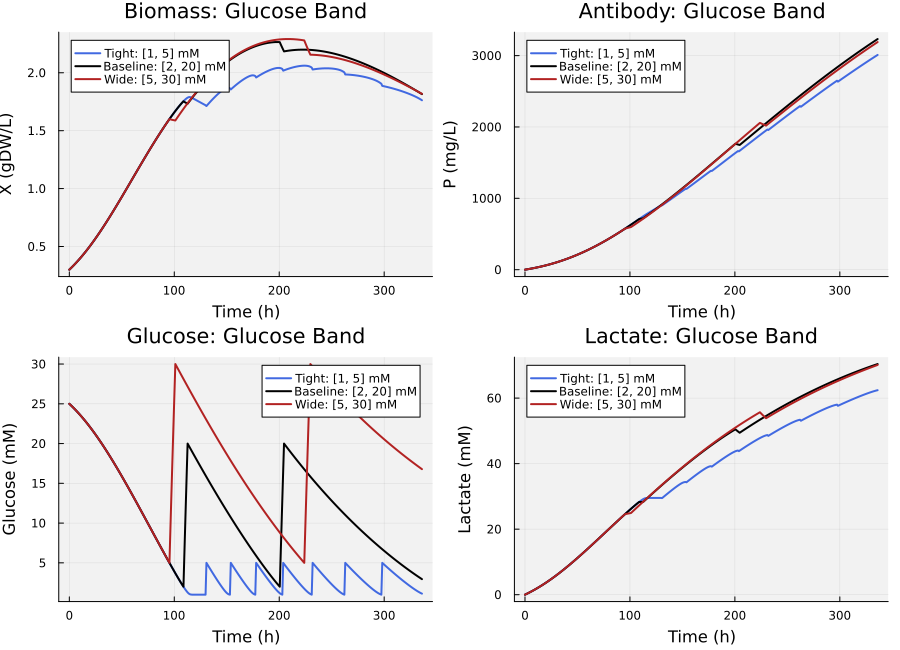

In [12]:
let
    vals = band_results;
    colors = [:royalblue, :black, :firebrick];

    # initialize subplots -
    p_X = plot(ylabel="X (gDW/L)",    xlabel="Time (h)", title="Biomass: Glucose Band",  legend=:topleft,  background_color_inside=:gray95);
    p_P = plot(ylabel="P (mg/L)",     xlabel="Time (h)", title="Antibody: Glucose Band", legend=:topleft,  background_color_inside=:gray95);
    p_G = plot(ylabel="Glucose (mM)", xlabel="Time (h)", title="Glucose: Glucose Band",  legend=:topright, background_color_inside=:gray95);
    p_L = plot(ylabel="Lactate (mM)", xlabel="Time (h)", title="Lactate: Glucose Band",  legend=:topleft,  background_color_inside=:gray95);

    # overlay each glucose band -
    for (i, sol) in enumerate(vals.solutions)
        X_t = [sol.u[j][2] for j in 1:length(sol.t)]; # biomass (index 2) -
        P_t = [sol.u[j][5] for j in 1:length(sol.t)]; # antibody (index 5) -
        G_t = [sol.u[j][3] for j in 1:length(sol.t)]; # glucose (index 3) -
        L_t = [sol.u[j][6] for j in 1:length(sol.t)]; # lactate (index 6) -
        plot!(p_X, sol.t, X_t, label=vals.labels[i], lw=2, color=colors[i]);
        plot!(p_P, sol.t, P_t, label=vals.labels[i], lw=2, color=colors[i]);
        plot!(p_G, sol.t, G_t, label=vals.labels[i], lw=2, color=colors[i]);
        plot!(p_L, sol.t, L_t, label=vals.labels[i], lw=2, color=colors[i]);
    end

    plot(p_X, p_P, p_G, p_L, layout=(2, 2), size=(900, 650))
end

A tight glucose band produces more regular feeding pulses and lower glucose variance. A wide band results in fewer, larger pulses with greater glucose excursion, which tends to produce more lactate during the high-glucose intervals. Finally, we explore how yield coefficients set the metabolic efficiency of the culture.

### 3c. Yield Coefficients
We sweep the lactate yield on glucose $Y_{lac/glc}$ and the biomass yield on glucose $Y_{X/glc}$ separately.

> __Metabolic efficiency and cost of goods__ are directly linked to yield coefficients. The biomass yield on glucose ($Y_{X/glc}$) determines how many cells are produced per unit of glucose consumed. Higher yield means less media per gram of cells, directly reducing the cost of goods in manufacturing. The lactate yield on glucose ($Y_{lac/glc}$) determines how much lactate is produced as a by-product of glucose metabolism. CHO cells with lower lactate yields (e.g., through metabolic engineering or media optimization) sustain growth longer because by-product inhibition is delayed. In a market where biologics media costs can exceed \$50/L, even small yield improvements translate to significant cost savings at manufacturing scale.

The four subplots show lactate $Lac$ (mM), biomass $X$ (gDW/L), and antibody $P$ (mg/L) trajectories.

In [13]:
yield_results = let
    colors = [:royalblue, :black, :firebrick];

    # --- Lactate yield sweep ---
    Y_lac_values = [0.7, 1.2, 1.6]; # mmol lactate / mmol glucose
    labels_Ylac = ["Y_lac/glc = 0.7 (low)", "Y_lac/glc = 1.2 (baseline)", "Y_lac/glc = 1.6 (high)"];
    sols_Ylac = Vector{Any}(undef, 3);
    for (i, Ylac) in enumerate(Y_lac_values)
        p = build_default_parameters(; F_max=0.10, Glc_min=2.0, Glc_max=20.0, Y_lac_glc=Ylac);
        sols_Ylac[i] = simulate_fedbatch(p; u0=copy(u0_baseline), tspan=tspan, saveat=saveat);
    end

    # --- Biomass yield sweep ---
    Y_X_glc_values = [0.035, 0.070, 0.12]; # gDW / mmol glucose
    labels_YXglc = ["Y_X/glc = 0.035 (low)", "Y_X/glc = 0.070 (baseline)", "Y_X/glc = 0.12 (high)"];
    sols_YXglc = Vector{Any}(undef, 3);
    for (i, YXglc) in enumerate(Y_X_glc_values)
        p = build_default_parameters(; F_max=0.10, Glc_min=2.0, Glc_max=20.0, Y_X_glc=YXglc);
        sols_YXglc[i] = simulate_fedbatch(p; u0=copy(u0_baseline), tspan=tspan, saveat=saveat);
    end

    # return results -
    (Ylac_labels=labels_Ylac, Ylac_sols=sols_Ylac, YXglc_labels=labels_YXglc, YXglc_sols=sols_YXglc)
end;

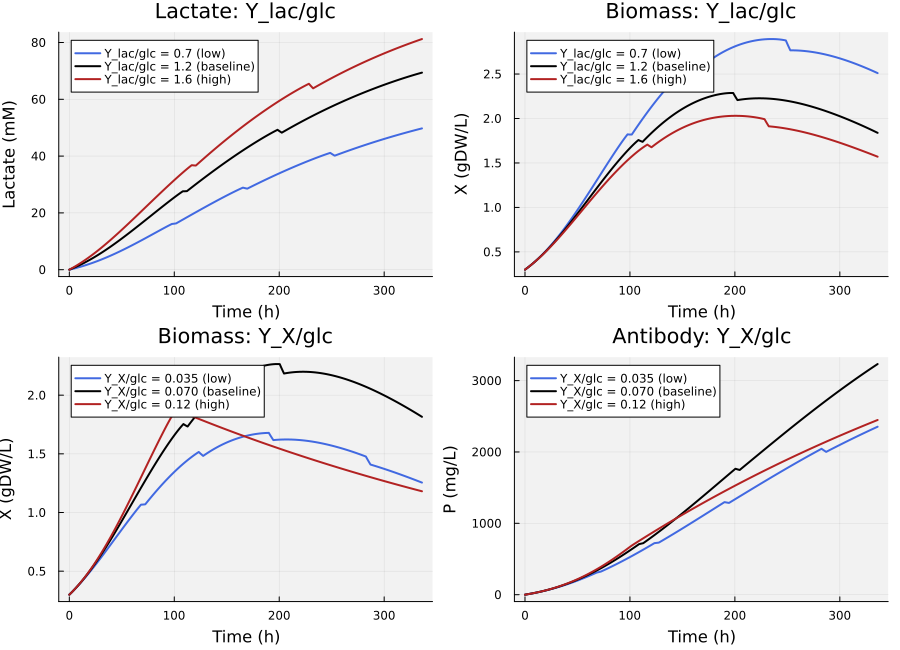

In [14]:
let
    res = yield_results;
    colors = [:royalblue, :black, :firebrick];

    # --- Top row: lactate yield ---
    p1 = plot(ylabel="Lactate (mM)", xlabel="Time (h)", title="Lactate: Y_lac/glc", legend=:topleft, background_color_inside=:gray95);
    p2 = plot(ylabel="X (gDW/L)",   xlabel="Time (h)", title="Biomass: Y_lac/glc", legend=:topleft, background_color_inside=:gray95);
    for (i, sol) in enumerate(res.Ylac_sols)
        L_t = [sol.u[j][6] for j in 1:length(sol.t)]; # lactate (index 6) -
        X_t = [sol.u[j][2] for j in 1:length(sol.t)]; # biomass (index 2) -
        plot!(p1, sol.t, L_t, label=res.Ylac_labels[i], lw=2, color=colors[i]);
        plot!(p2, sol.t, X_t, label=res.Ylac_labels[i], lw=2, color=colors[i]);
    end

    # --- Bottom row: biomass yield ---
    p3 = plot(ylabel="X (gDW/L)", xlabel="Time (h)", title="Biomass: Y_X/glc",  legend=:topleft, background_color_inside=:gray95);
    p4 = plot(ylabel="P (mg/L)",  xlabel="Time (h)", title="Antibody: Y_X/glc", legend=:topleft, background_color_inside=:gray95);
    for (i, sol) in enumerate(res.YXglc_sols)
        X_t = [sol.u[j][2] for j in 1:length(sol.t)]; # biomass (index 2) -
        P_t = [sol.u[j][5] for j in 1:length(sol.t)]; # antibody (index 5) -
        plot!(p3, sol.t, X_t, label=res.YXglc_labels[i], lw=2, color=colors[i]);
        plot!(p4, sol.t, P_t, label=res.YXglc_labels[i], lw=2, color=colors[i]);
    end

    plot(p1, p2, p3, p4, layout=(2, 2), size=(900, 650))
end

Higher $Y_{lac/glc}$ drives lactate accumulation, which inhibits growth through the Monod inhibition term. A higher $Y_{X/glc}$ produces more biomass per glucose consumed, which also increases antibody secretion. We now compare all parameter variations in a summary table.

### Scenario Comparison Table
We run a grid of scenarios and compare the final antibody titer, peak biomass, peak lactate, and peak ammonia. Each row corresponds to a single 14-day simulation with one parameter changed from its baseline value. The results are stored in a `DataFrame` and displayed with [the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/).

In [15]:
let
    # define scenarios: each row varies one parameter from baseline -
    scenarios = [
        (label="Baseline",            F_max=0.10,  Glc_min=2.0, Glc_max=20.0, extra=NamedTuple()),
        (label="Fast feed",           F_max=0.50,  Glc_min=2.0, Glc_max=20.0, extra=NamedTuple()),
        (label="Slow feed",           F_max=0.025, Glc_min=2.0, Glc_max=20.0, extra=NamedTuple()),
        (label="Tight glucose band",  F_max=0.10,  Glc_min=1.0, Glc_max=5.0,  extra=NamedTuple()),
        (label="Wide glucose band",   F_max=0.10,  Glc_min=5.0, Glc_max=30.0, extra=NamedTuple()),
        (label="High \u03bc_max",     F_max=0.10,  Glc_min=2.0, Glc_max=20.0, extra=(mu_max=0.050,)),
        (label="Low \u03bc_max",      F_max=0.10,  Glc_min=2.0, Glc_max=20.0, extra=(mu_max=0.025,)),
        (label="Lac-sensitive cells", F_max=0.10,  Glc_min=2.0, Glc_max=20.0, extra=(K_I_lac=20.0,)),
        (label="Lac-tolerant cells",  F_max=0.10,  Glc_min=2.0, Glc_max=20.0, extra=(K_I_lac=80.0,)),
        (label="High Y_lac/glc",      F_max=0.10,  Glc_min=2.0, Glc_max=20.0, extra=(Y_lac_glc=1.6,)),
        (label="Low Y_lac/glc",       F_max=0.10,  Glc_min=2.0, Glc_max=20.0, extra=(Y_lac_glc=0.7,)),
        (label="High alpha_P",        F_max=0.10,  Glc_min=2.0, Glc_max=20.0, extra=(alpha_P=200.0,)),
    ];

    # simulate each scenario and collect endpoint metrics -
    rows = NamedTuple[];
    for s in scenarios
        p = build_default_parameters(; F_max=s.F_max, Glc_min=s.Glc_min, Glc_max=s.Glc_max, s.extra...);
        sol = simulate_fedbatch(p; u0=copy(u0_baseline), tspan=tspan, saveat=saveat);

        # extract endpoint metrics from the ODE solution -
        P_final  = sol.u[end][5];                                     # final antibody titer (index 5) -
        X_peak   = maximum(sol.u[i][2] for i in 1:length(sol.t));     # peak biomass (index 2) -
        Lac_peak = maximum(sol.u[i][6] for i in 1:length(sol.t));     # peak lactate (index 6) -
        Amm_peak = maximum(sol.u[i][7] for i in 1:length(sol.t));     # peak ammonia (index 7) -

        push!(rows, (
            Scenario         = s.label,
            Titer_mg_L       = round(P_final,  digits=1),
            Peak_Biomass_gDW = round(X_peak,   digits=2),
            Peak_Lac_mM      = round(Lac_peak, digits=1),
            Peak_Amm_mM      = round(Amm_peak, digits=2),
        ));
    end

    # display formatted table -
    df = DataFrame(rows);
    pretty_table(df;
        backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__simple),
        alignment = [:l, :r, :r, :r, :r]
    )
end

====================== ============ ================== ============= ==============
  Scenario              Titer_mg_L   Peak_Biomass_gDW   Peak_Lac_mM   Peak_Amm_mM 
  String                   Float64            Float64       Float64       Float64 
====================== ============ ================== ============= ==============
  Baseline                  3232.1               2.27          70.4         12.78
  Fast feed                 3121.1               2.26          70.1         12.73
  Slow feed                 3198.1               2.27          69.9         12.69
  Tight glucose band        3009.3               2.06          62.4         11.33
  Wide glucose band         3189.9               2.29          70.1         12.73
  High μ_max                3946.7               2.85          97.2         17.65
  Low μ_max                 2979.4               2.13          62.8         11.41
  Lac-sensitive cells       2717.9               1.92          52.6          9.55
  Lac-tole

The table shows that biological parameters (growth rate, inhibition) and process parameters (feed rate, glucose band, yields) each produce distinct tradeoffs. Lactate-sensitive cells and high lactate yields both reduce peak biomass and titer through the same inhibition mechanism, while fast feed rates increase titer at the cost of higher by-product levels and reactor volume.
___

## Summary
A seven-state ODE model captures the coupled dynamics of a fed-batch CHO bioreactor under a glucose-triggered feed policy.

> __Key Takeaways:__
>
> * __Growth rate and by-product inhibition set biological limits on achievable biomass and titer:__ The maximum growth rate determines how fast the culture expands, while the inhibition constants determine when accumulated lactate and ammonia arrest growth. These are properties of the cell line that are selected during clone development.
> * __Feed policy and yield coefficients are the engineer's primary handles for optimizing productivity:__ The feed rate, glucose control band, and yield coefficients determine nutrient delivery, metabolic efficiency, and by-product management within the biological limits set by the cell line.
> * __The CHO model provides structured training data for the LSTM:__ The parameter sweeps in this notebook demonstrate the range of dynamics that the LSTM must learn to predict in the [companion example](CHEME-5820-L12c-Example-LSTM-CHO-Spring-2026.ipynb).

The scenario comparison table shows that growth kinetics, feed policy, and yield coefficients each produce distinct tradeoffs between titer, biomass, and by-product accumulation. The parameter sweeps in this notebook establish the data-generating process used to train the LSTM in the companion example.
___